In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# zainicjowanie ziarna
np.random.seed(123)

N_values = [100, 1000, 10000, 100000]
pi_true = np.pi

def monte_carlo_pi(N):
    x = np.random.uniform(0, 1, N)
    y = np.random.uniform(0, 1, N)
    colors = ['red' if x_i**2 + y_i**2 <= 1 else 'blue' for x_i, y_i in zip(x, y)]
    data = pd.DataFrame({'x': x, 'y': y, 'colors': colors})
    nred = data.colors.value_counts().get('red', 0)
    nall = N
    area = nred / nall
    pi_estimate = 4 * area
    return pi_estimate, data

def monte_carlo_moment(number_of_points):
    success = 0
    res = []
    for i in range(1, number_of_points+1):
        x = np.random.uniform(0, 1.1)
        y = np.random.uniform(0, 1.1)
        if x**2 + y**2 <= 1:
            success += 1
        res.append(4*success/i*1.1*1.1)
    return res

def plot_histogram(ax, pi_estimations, N):
    ax.hist(pi_estimations, bins=10, edgecolor='black', alpha=0.7, density=True)
    ax.axvline(pi_true, color='red', linestyle='-', label=f'π = {pi_true:.4f}')
    ax.set_title(f'Rozkład estymacji π - N={N}')
    ax.set_xlabel('Estymacja π')
    ax.set_ylabel('Częstotliwość')
    ax.legend()

<ipython-input-26-7b5f76ddae48>:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()
<ipython-input-26-7b5f76ddae48>:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()
<ipython-input-26-7b5f76ddae48>:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()
<ipython-input-26-7b5f76ddae48>:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


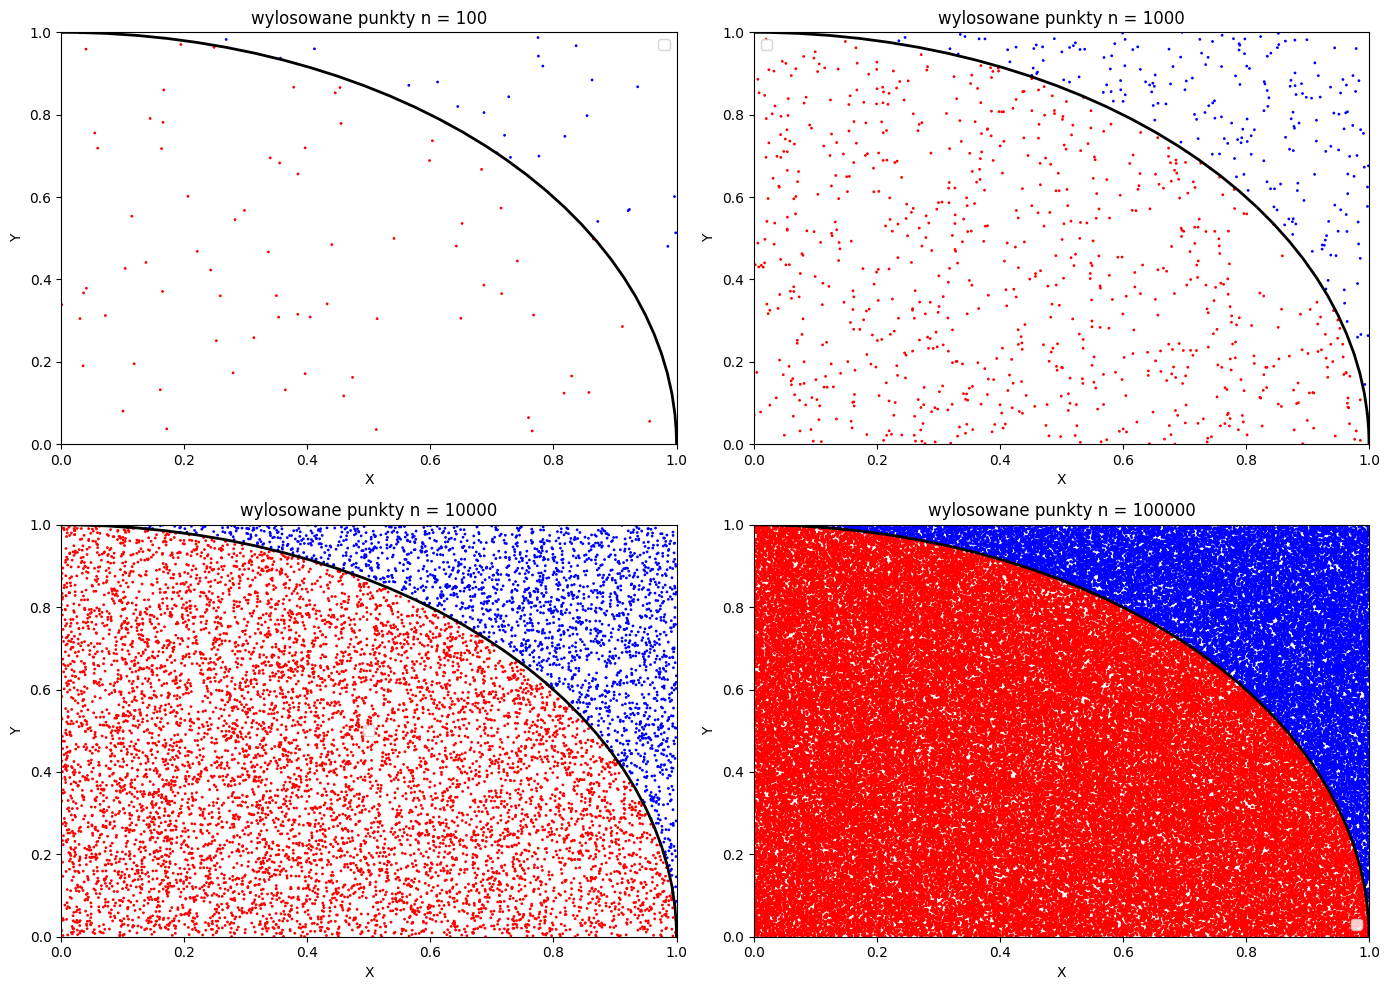

In [26]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

N_values = [100, 1000, 10000, 100000]
for i, N in enumerate(N_values):
    ax = axes[i // 2, i % 2]
    pi_estimations, data = monte_carlo_pi(N)
    ax.scatter(data.x, data.y, c=data['colors'], s=1)
    circle = plt.Circle((0, 0), 1, color='black', fill=False, linewidth=2)
    ax.add_patch(circle)
    ax.set_title(f'wylosowane punkty n = {N}')
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.legend()

plt.tight_layout()
plt.show()

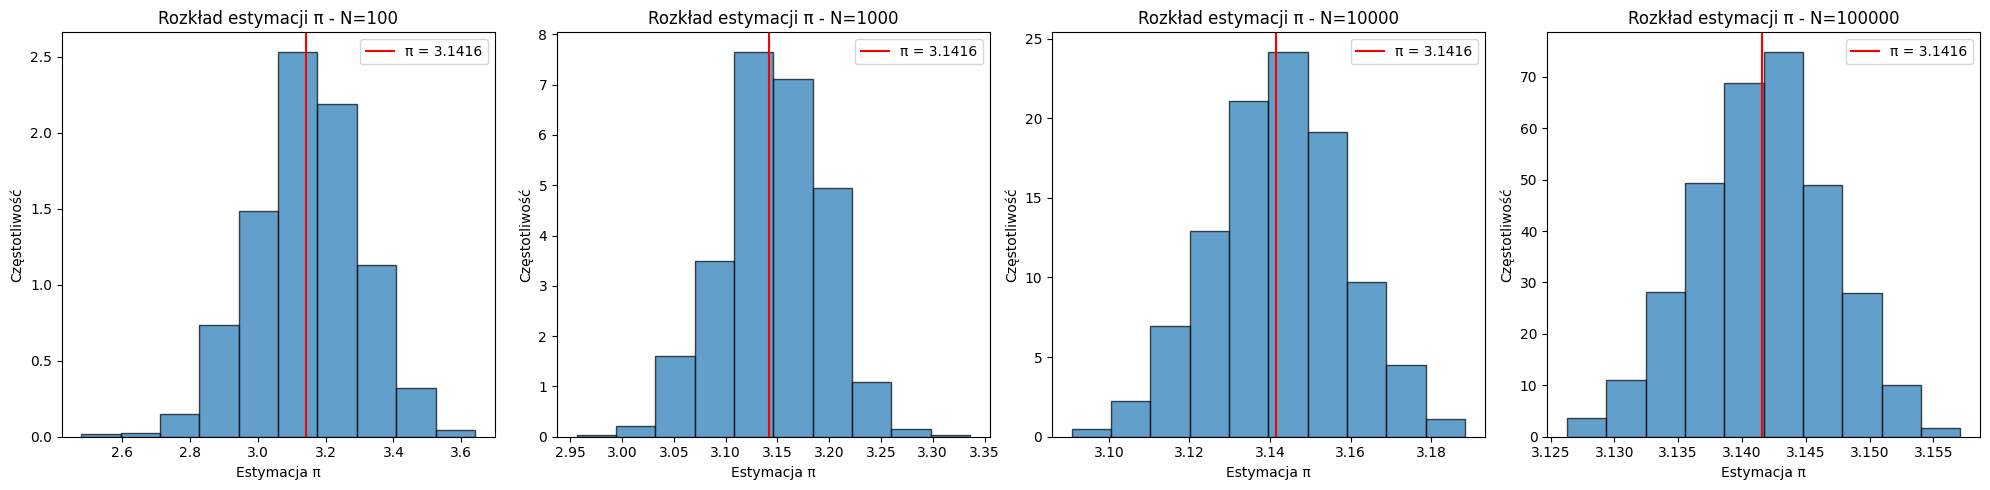

In [29]:
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
for i, N in enumerate(N_values):
    ax = axes[i]
    pi_estimations = []
    for _ in range(1000):
        pi_estimate, _ = monte_carlo_pi(N)
        pi_estimations.append(pi_estimate)
    plot_histogram(ax, pi_estimations, N)

plt.tight_layout()
plt.show()

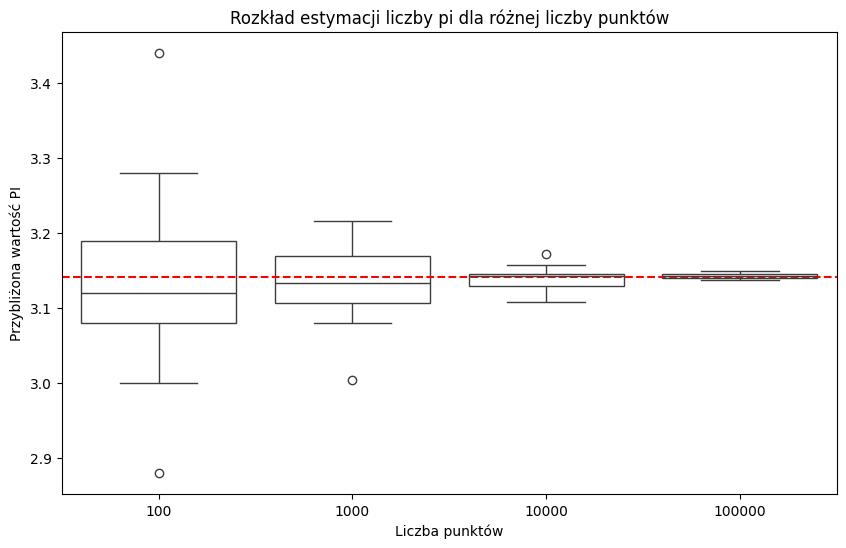

In [27]:
results = {n: [] for n in N_values}

for n in N_values:
    for _ in range(10):
        results[n].append(monte_carlo_pi(n)[0])

data = pd.DataFrame({key: value for key, value in results.items()})
plt.figure(figsize=(10, 6))
sns.boxplot(data=data, color='white')
plt.axhline(y=pi_true, color='r', linestyle='--', linewidth=1.5)
plt.xlabel("Liczba punktów")
plt.ylabel("Przybliżona wartość PI")
plt.title("Rozkład estymacji liczby pi dla różnej liczby punktów")
plt.show()

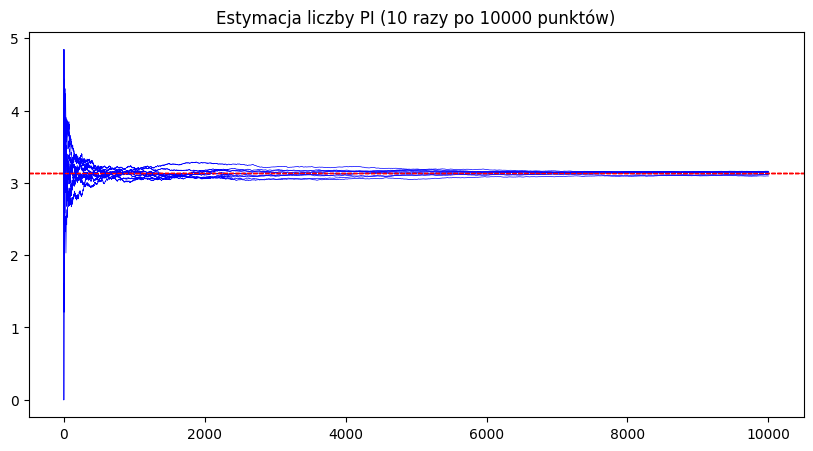

In [14]:
plt.figure(figsize=(10, 5))
for i in range(10):
    pis = monte_carlo_moment(10000)
    x = np.arange(1, 10001, 1)
    plt.plot(x, pis, linewidth=0.5, c='blue')
    plt.axhline(y=3.14159265359, color='r', linestyle='--', linewidth=0.8)
    plt.title(f'Estymacja liczby PI (10 razy po 10000 punktów)')

1. Cel algorytmu: Algorytm Monte Carlo służy w naszym zadaniu do estymacji wartości liczby 𝜋, poprzez losowanie punktów w jednostkowym kwadracie i sprawdzanie, ile z tych punktów leży w ćwiartce okręgu. Następnie na podstawie stosunku liczby punktów wewnątrz okręgu do całkowitej liczby punktów, możemy oszacować wartość 𝜋.

2. Kroki algorytmu: Losowanie punktów: Na początku generujemy 𝑁 punktów losowo w jednostkowym kwadracie. Współrzędne punktów 𝑥 , 𝑦 są wybierane losowo z zakresu [0, 1]. Sprawdzanie, czy punkt należy do ćwiartki okręgu: Dla każdego punktu sprawdzamy, czy spełnia ono równanie 𝑥2 +𝑦2 ≤ 1, które określa, czy punkt znajduje się wewnątrz ćwiartki okręgu o promieniu 1 (rozważamy tylko ćwiartkę okręgu, bo działamy w jednostkowym kwadracie). Obliczenie estymacji 𝜋:
Estymacja 𝜋 obliczana jest jako stosunek punktów znajdujących się w okręgu do wszystkich punktów, pomnożony przez 4 (ponieważ pełny okrąg to 4 ćwiartki w jednostkowym kwadracie).
Powtarzanie procesu: Aby uzyskać dokładniejszy wynik, powtarzamy proces wielu razy (np. 100 prób dla różnych wartości 𝑁
N), dla różnych liczb punktów (100, 1000, 10000, 100000).
Wizualizacja: Na końcu możemy zobaczyć, jak rozkładają się punkty, czy leżą w obrębie ćwiartki okręgu, oraz jak wartości 𝜋 zmieniają się wraz ze wzrostem liczby punktów. Możemy również wyświetlić histogramy estymacji π, wykresy pudełkowe i inne statystyki.

3. Wnioski:
Dokładność algorytmu rośnie z większą liczbą punktów: Im więcej punktów losujemy (większe 𝑁, tym dokładniejsze staje się nasze oszacowanie liczby 𝜋
Przy bardzo małych 𝑁 (np. 100) estymacja może być bardzo nieprecyzyjna, ale już przy 𝑁 = 10000 i więcej wartości zaczynają się stabilizować i zbliżać do rzeczywistej wartości 𝜋. Widać to na wykresach pudełkowych, gdzie dla mniejszych 𝑁 mamy większą rozpiętość wartości, a dla większych wartości ta rozpiętość maleje.

4. Wydajność algorytmu: Choć algorytm Monte Carlo jest prosty do zaimplementowania, jego dokładność jest ograniczona przez liczbę losowanych punktów. Przy bardzo dużych wartościach
𝑁(np. N=1000000) algorytm może być czasochłonny, a jego wydajność będzie zależała od mocy obliczeniowej.